# Cross-Exchange ETF Time-Series Modeling

This notebook presents a cleaned version of the econometrics assignment using the same ETF across three trading venues. The goal is to separate short-run return dynamics, cross-market interactions, long-run equilibrium, and volatility behavior into one readable workflow.

## Modeling Setup

I use three related representations of the same data:

- daily closing returns for ARMA and GARCH,
- 15-minute aligned returns for VAR,
- sampled 15-minute log prices for VECM.

The main return definition is

$$
r_t = 100 \cdot \left(\log P_t - \log P_{t-1}\right).
$$

For the multivariate system, the core ideas are

$$
y_t = c + A_1 y_{t-1} + \cdots + A_p y_{t-p} + u_t
$$

for the VAR, and

$$
\Delta y_t = \alpha \beta^\prime y_{t-1} + \Gamma_1 \Delta y_{t-1} + \cdots + \Gamma_k \Delta y_{t-k} + u_t
$$

for the VECM. The volatility section compares conditional variance estimates against realized variance built from intraday squared returns.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_DIR = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_DIR / "src"))

from analysis import run_analysis

pd.set_option("display.float_format", lambda value: f"{value:0.4f}")
results = run_analysis(PROJECT_DIR)
arma_table = results["arma_table"]
var_table = results["var_table"]
vecm_table = results["vecm_table"]
volatility_table = results["volatility_table"]


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


## Sample Overview

The processed file already contains minute-level prices for the three venues, which makes it possible to move between frequencies without rebuilding the raw Excel pipeline inside the portfolio repo.

In [2]:
wide_prices = results["wide_prices"]
print({
    "venues": list(wide_prices.columns),
    "minute_observations": len(wide_prices),
    "start": str(wide_prices.index.min()),
    "end": str(wide_prices.index.max()),
})

{'venues': ['SPY5.P', 'SPY5.SIX', 'SPY5l.CHIX'], 'minute_observations': 217348, 'start': '2024-01-02 09:00:00', 'end': '2025-08-29 17:29:00'}


## ARMA Model Selection

I estimate the full $3 \times 3$ grid of ARMA$(p,q)$ models for daily closing returns of `SPY5.SIX`. The comparison uses information criteria, out-of-sample mean squared error, and a Ljung-Box residual check.

In [3]:
arma_table

,p,q,aic,bic,log_likelihood,oos_mse,ljung_box_pvalue
0,1,2,568.3947,585.9819,-279.1973,1.4093,0.8712
1,0,2,569.5841,583.6539,-280.7920,1.4157,0.8030
2,0,1,569.6357,580.2001,-281.8178,1.4160,0.7613
3,0,0,569.7054,576.7563,-282.8527,1.4152,0.7543
4,2,2,570.2198,591.3245,-279.1099,1.4094,0.8801
5,2,0,570.8743,584.9601,-281.4371,1.4160,0.7969
6,1,0,571.6208,582.1972,-282.8104,1.4153,0.7610
7,1,1,571.6349,585.7207,-281.8174,1.4160,0.7610
8,2,1,572.8717,590.4790,-281.4358,1.4160,0.7956


In [4]:
print(f"ARCH LM statistic: {results['arch_lm'][0]:0.4f}")
print(f"ARCH LM p-value: {results['arch_lm'][1]:0.4f}")

ARCH LM statistic: 11.5057
ARCH LM p-value: 0.0422


## Intraday Cross-Exchange Dynamics

The VAR section works on 15-minute aligned returns. The comparison between `VAR(2)` and `VAR(5)` is mainly about whether extra lag depth improves fit or forecasting in a meaningful way.

In [5]:
var_table

,model,aic,bic,log_likelihood,mse_SPY5.P,mse_SPY5.SIX,mse_SPY5l.CHIX
0,VAR(2),-14.1920,-14.1744,23782.2307,0.0777,0.0923,0.1028
1,VAR(5),-14.1973,-14.1569,23822.6699,0.0777,0.0923,0.1028


## Cointegration In Prices

The three price series should share the same underlying market trend, so the relevant question is not whether each price level is stationary, but whether they move together over time. The VECM adjustment coefficients show which venues respond more strongly when that equilibrium is disturbed.

In [6]:
vecm_table

,symbol,ec1,ec2,adf_pvalue,cointegration_rank,lag_order
0,SPY5.P,-0.0270,-0.2451,0.6908,2,2
1,SPY5.SIX,0.3316,-0.6144,0.6786,2,2
2,SPY5l.CHIX,0.3354,-0.2648,0.7008,2,2


## Volatility Modeling

The volatility section compares several GARCH-family models on daily returns and then relates the best conditional variance paths to realized variance constructed from intraday data.

In [7]:
volatility_table

,model,aic,bic,log_likelihood
0,"GARCH(1,1)",1038.2032,1058.3204,-514.1016
1,"EGARCH(1,1)",1039.0728,1059.1900,-514.5364
2,"GARCH(2,2)",1039.9463,1068.1104,-512.9731
3,"GARCH(1,2)",1040.0571,1064.1978,-514.0286
4,"GARCH(2,1)",1040.2032,1064.3439,-514.1016
5,"EGARCH(1,2)",1041.0072,1065.1479,-514.5036
6,"EGARCH(2,1)",1041.0333,1065.1740,-514.5166
7,"EGARCH(2,2)",1041.4646,1069.6288,-513.7323


## Visual Summary

The figures below summarize the main diagnostics: daily autocorrelation structure, cross-market residual correlation, and the comparison between realized variance and fitted conditional variance.

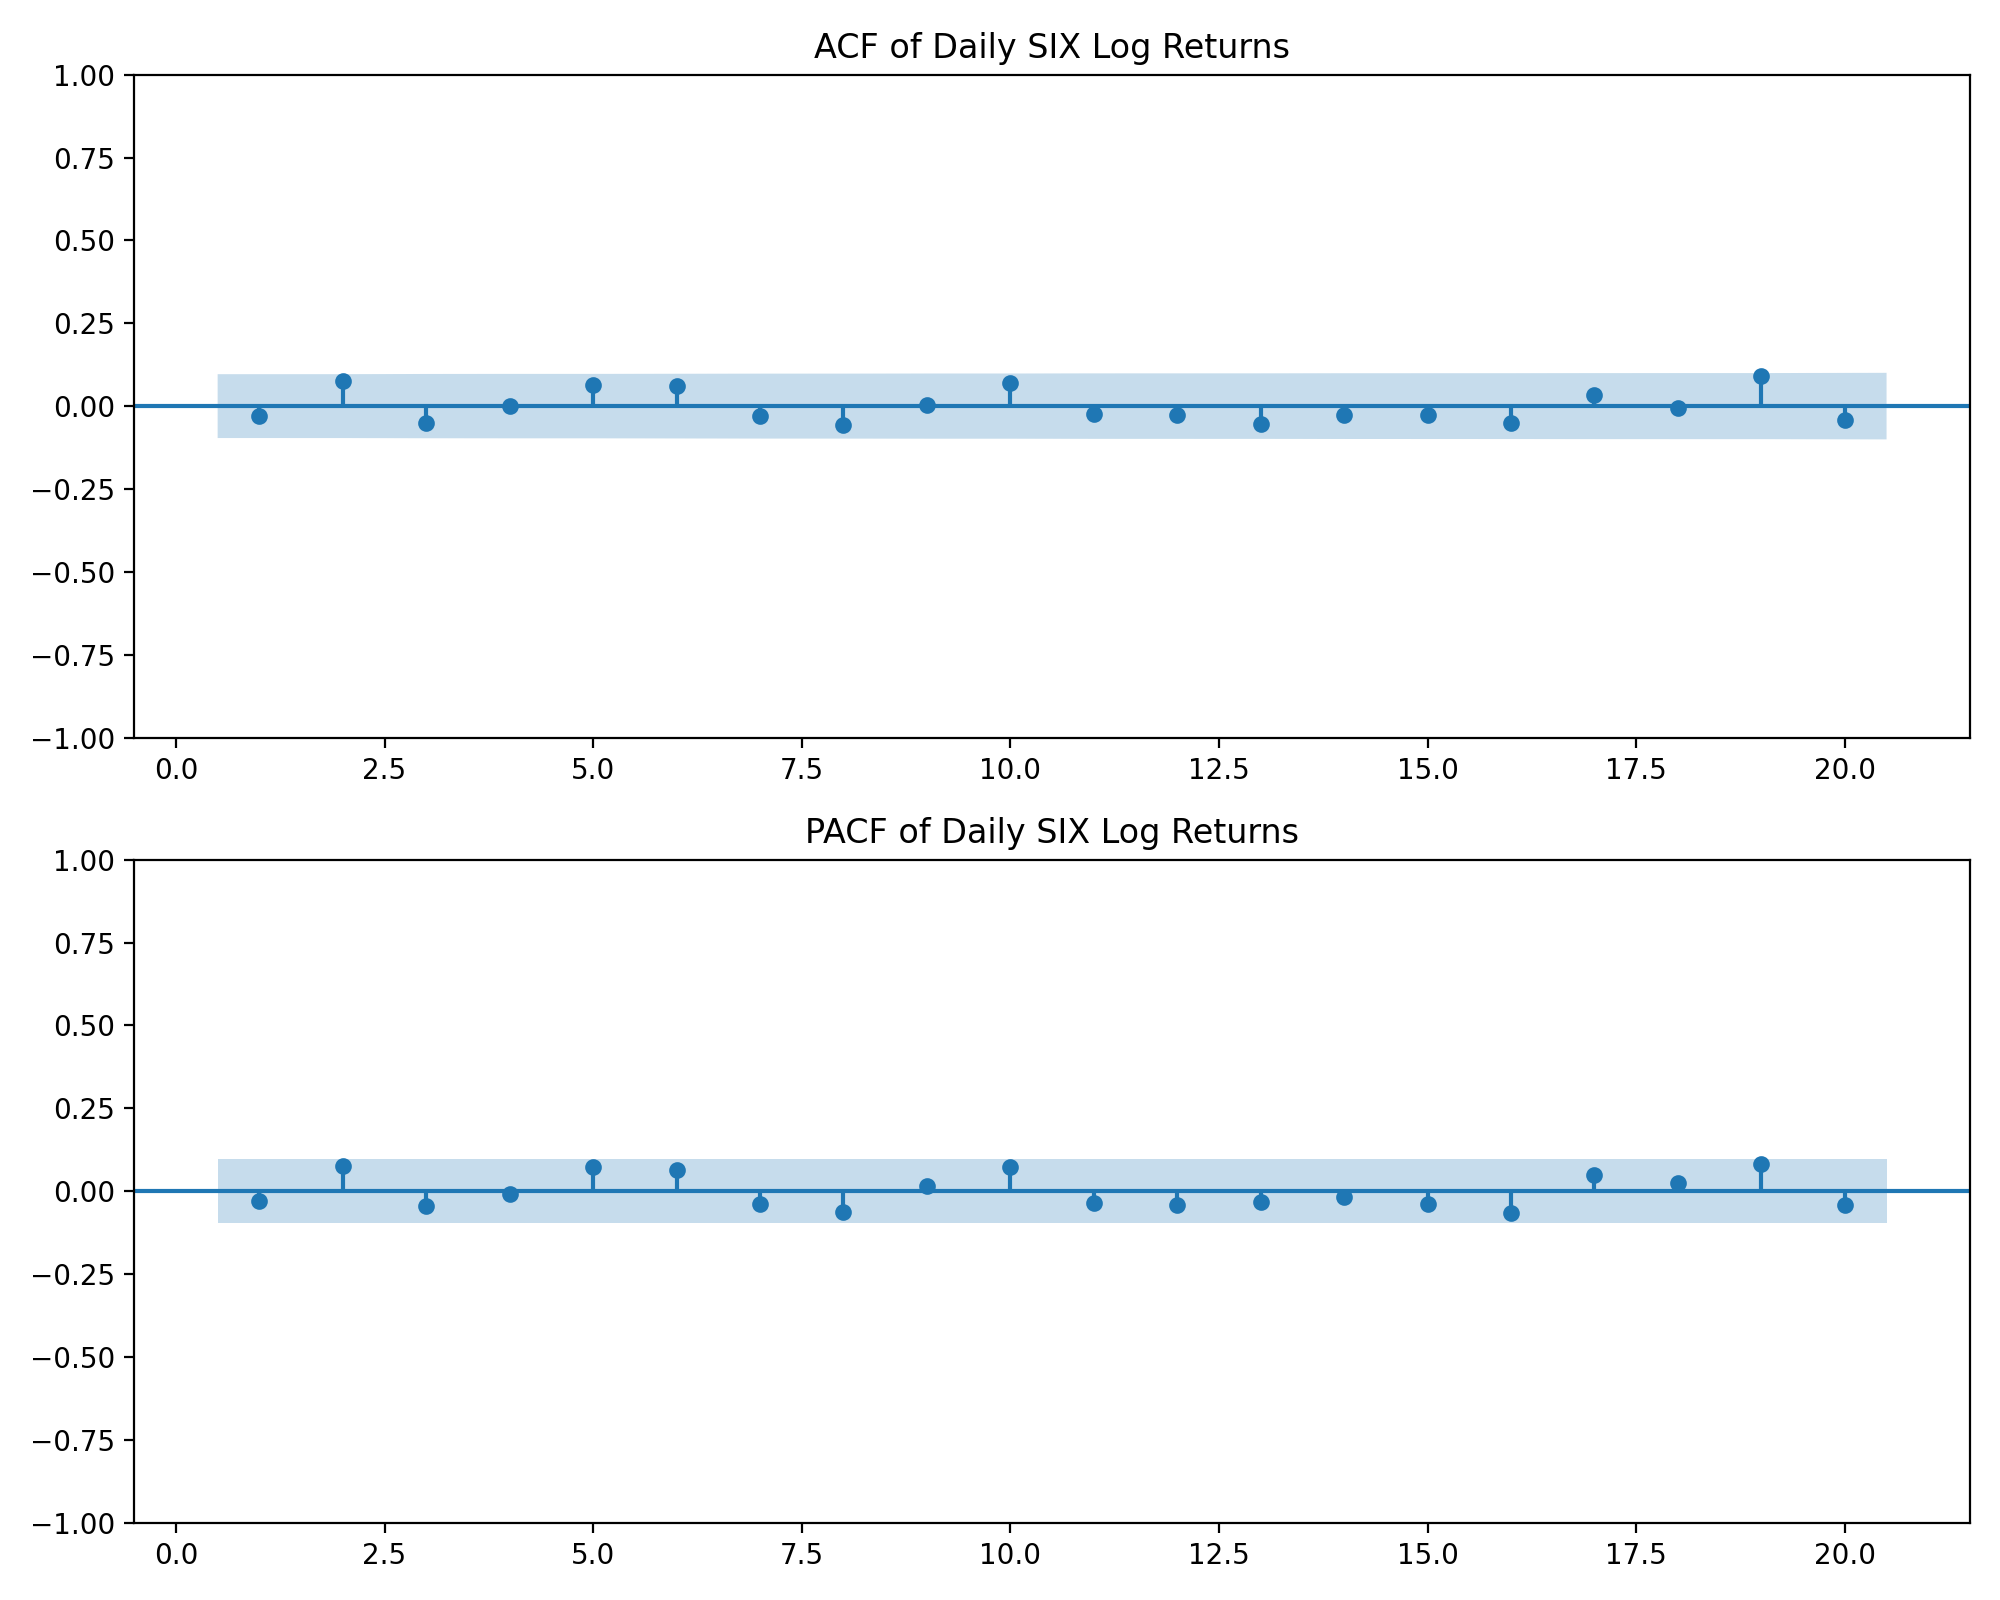

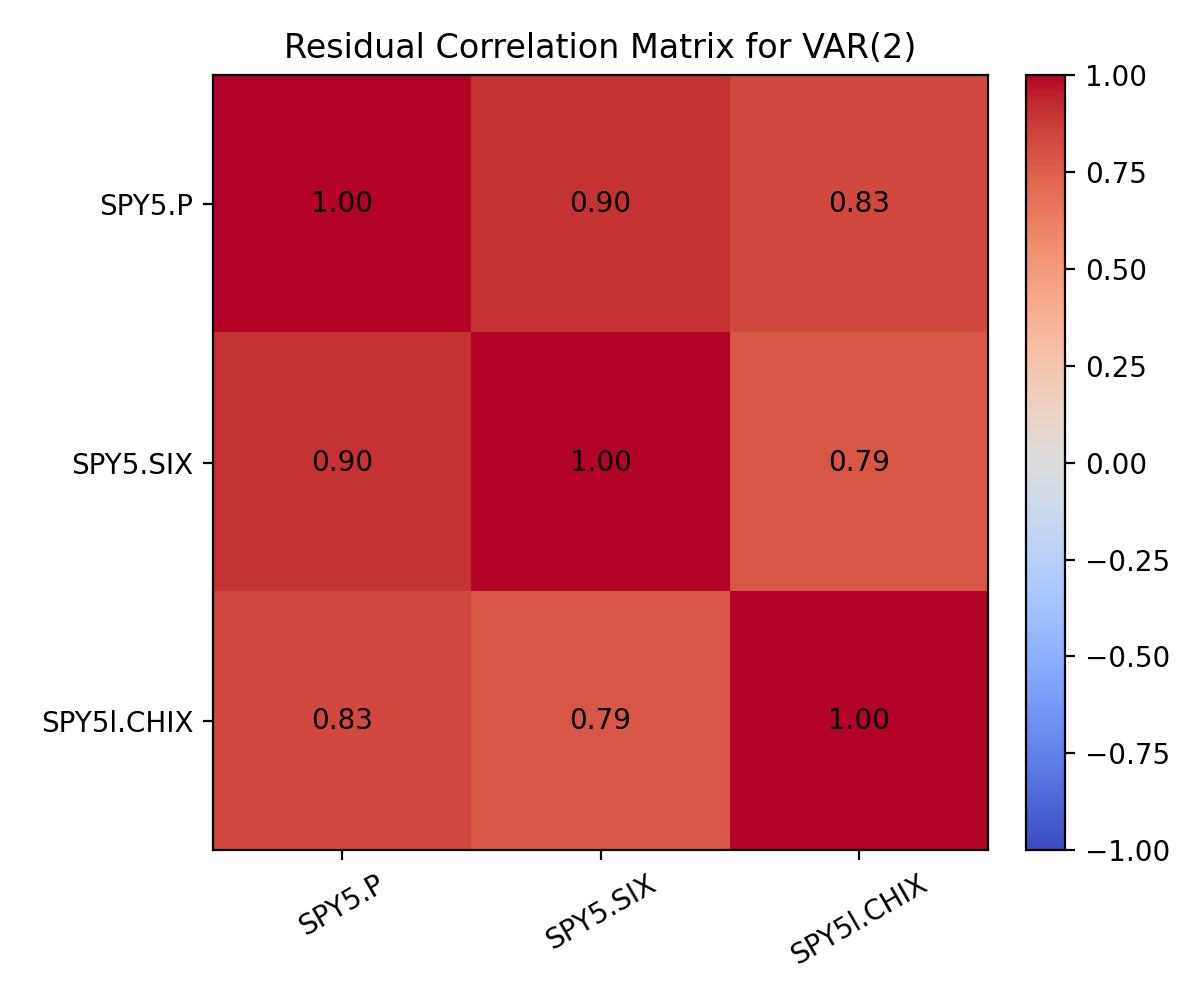

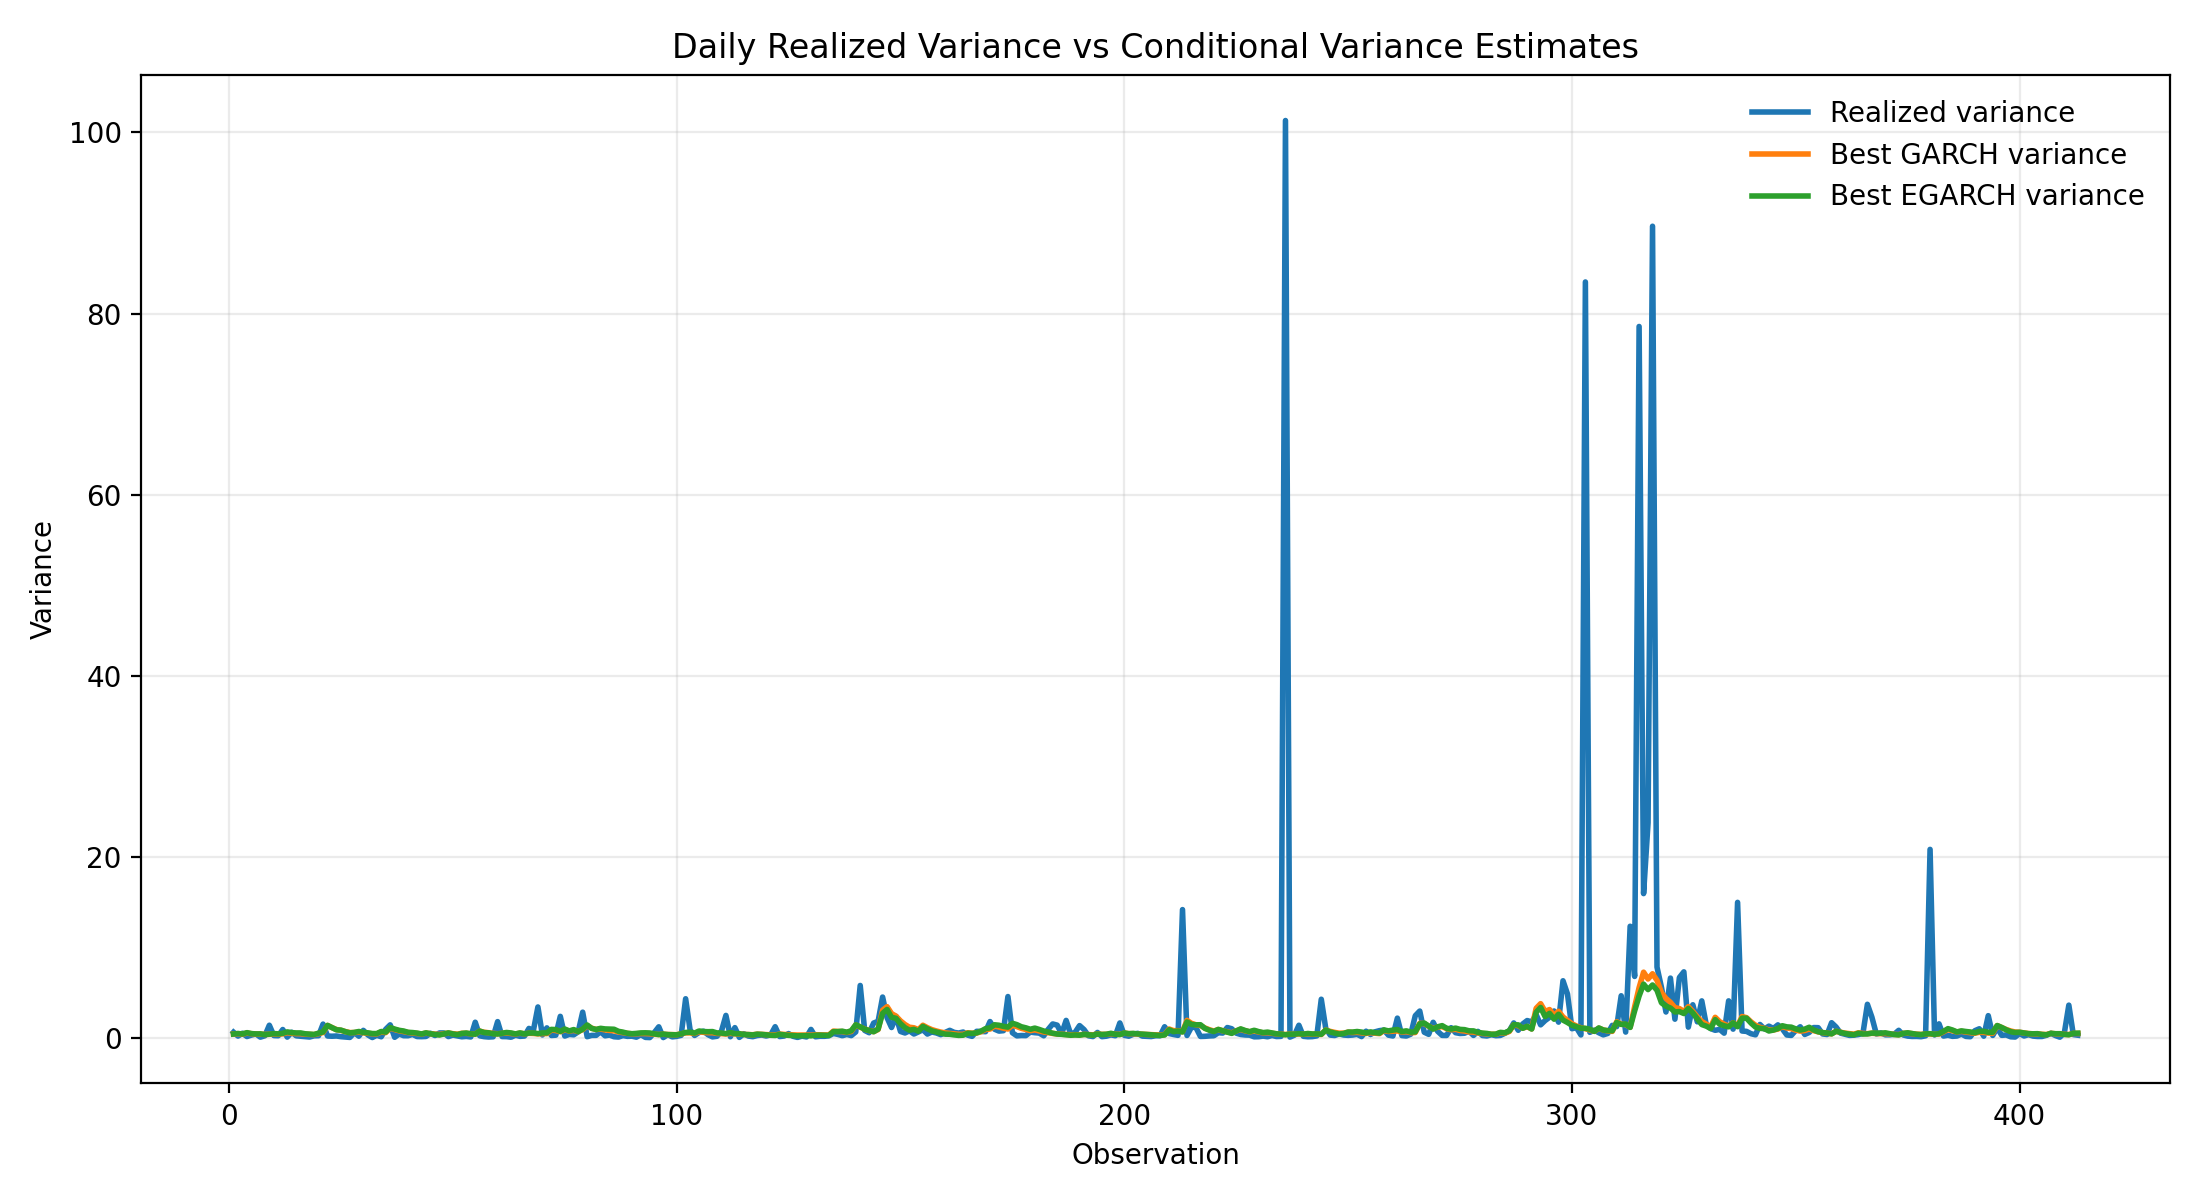

In [8]:
display(Image(filename=str(PROJECT_DIR / "figures" / "daily_return_acf_pacf.png")))
display(Image(filename=str(PROJECT_DIR / "figures" / "var2_residual_correlation.png")))
display(Image(filename=str(PROJECT_DIR / "figures" / "realized_vs_model_variance.png")))

## Takeaways

- A low-order ARMA model is enough for the daily mean dynamics; richer specifications only improve the fit marginally.
- The extra lag depth in `VAR(5)` does not translate into materially better forecasting than `VAR(2)`.
- The three venue price series remain cointegrated, which is what we would expect for multiple listings of the same ETF.
- Volatility clustering is present, and the GARCH-family models smooth the same bursts that realized variance captures more sharply.

Overall, the project shows how univariate, multivariate, and volatility models can be combined in one market microstructure-style setting without turning the workflow into a long notebook dump.